In [3]:
import pandas as pd
import numpy as np
import os

# Excel dosyasını okuyalım
filename = 'mergeAllData.xlsx'

if os.path.exists(filename):
    # Not: Eğer birden fazla sayfa varsa sheet_name='Sheet1' eklenebilir
    df = pd.read_excel(filename) 
    print("Veri başarıyla yüklendi!")
    print("Veri Boyutu:", df.shape)
    print("\nSütunlar:", df.columns.tolist())
    display(df.head())
else:
    print(f"HATA: '{filename}' dosyası bulunamadı. Lütfen dosyanın VS Code'da açtığın klasörün içinde olduğundan emin ol.")

Veri başarıyla yüklendi!
Veri Boyutu: (43460, 12)

Sütunlar: ['Hasta No', 'Örnek Tarihi', 'Yaş', 'Cinsiyet', 'Açlık Kan Şekeri (AKŞ)', 'Hemoglobin (Hb A1c)', 'Kolesterol (Total)', 'Kolestrol (HDL)', 'Kolestrol (LDL)', 'Tokluk Kan Şekeri (TKŞ) 1.Saat', 'Tokluk Kan Şekeri (TKŞ) 2.Saat', 'Trigliserid']


,Hasta No,Örnek Tarihi,Yaş,Cinsiyet,Açlık Kan Şekeri (AKŞ),Hemoglobin (Hb A1c),Kolesterol (Total),Kolestrol (HDL),Kolestrol (LDL),Tokluk Kan Şekeri (TKŞ) 1.Saat,Tokluk Kan Şekeri (TKŞ) 2.Saat,Trigliserid
0,1000322,2025-02-19,79 yıl,Erkek,106,"6,0","187,8","75,7","97,08",NaN,NaN,"75,1"
1,1000322,2025-03-01,78 yıl,Erkek,"131,9",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1000525,2025-08-19,55 yıl,Erkek,"151,4","7,0","198,6","45,4","86,56",NaN,NaN,"333,2"
3,1000857,2025-08-12,60 yıl,Kadın,"100,2",NaN,"247,1","71,5","155,34",NaN,NaN,"101,3"
4,1001036,2025-12-06,38 yıl,Kadın,"80,8",NaN,"134,7","69,8","54,5",NaN,NaN,52


In [4]:
# Kullanılacak sütunları seçelim
selected_columns = [
    'Yaş', 'Cinsiyet', 'Açlık Kan Şekeri (AKŞ)', 
    'Tokluk Kan Şekeri (TKŞ) 1.Saat', 'Tokluk Kan Şekeri (TKŞ) 2.Saat', 
    'Hemoglobin (Hb A1c)'
]

# Sadece mevcut olan sütunları filtreleyelim (Hata almamak için)
df_model = df[[c for c in selected_columns if c in df.columns]].copy()

# Sayısal temizlik fonksiyonu (Virgül -> Nokta ve Metin temizliği)
def clean_numeric(val):
    if pd.isna(val): return np.nan
    if isinstance(val, (int, float)): return float(val)
    val = str(val).replace(',', '.')
    # Rakam ve nokta dışındaki karakterleri (örn: " yıl") temizle
    val = ''.join(c for c in val if c.isdigit() or c == '.')
    try:
        return float(val)
    except:
        return np.nan

# Sayısal sütunları dönüştürelim
numeric_cols = ['Yaş', 'Açlık Kan Şekeri (AKŞ)', 'Tokluk Kan Şekeri (TKŞ) 1.Saat', 
                'Tokluk Kan Şekeri (TKŞ) 2.Saat', 'Hemoglobin (Hb A1c)']

for col in numeric_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].apply(clean_numeric)

# Cinsiyet: Erkek -> 1, Kadın -> 0 (Verideki yazıma göre kontrol edilmeli)
df_model['Cinsiyet'] = df_model['Cinsiyet'].map({'Erkek': 1, 'Kadın': 0})

# Hedef değişken (HbA1c) boş olan satırları atalım
df_model = df_model.dropna(subset=['Hemoglobin (Hb A1c)'])

print("Temizlik sonrası veri boyutu:", df_model.shape)
print("\nEksik Veri Sayıları (NaN):")
print(df_model.isnull().sum())

# Sınıf dağılımını görelim
def categorize_hba1c(x):
    if x < 5.7: return 'Diyabet Yok'
    elif 5.7 <= x < 6.5: return 'Pre-Diyabet'
    else: return 'Diyabet'

df_model['Durum'] = df_model['Hemoglobin (Hb A1c)'].apply(categorize_hba1c)
print("\nSınıf Dağılımı:")
print(df_model['Durum'].value_counts())

Temizlik sonrası veri boyutu: (25195, 6)

Eksik Veri Sayıları (NaN):
Yaş                                   0
Cinsiyet                              0
Açlık Kan Şekeri (AKŞ)             1646
Tokluk Kan Şekeri (TKŞ) 1.Saat    24214
Tokluk Kan Şekeri (TKŞ) 2.Saat    24151
Hemoglobin (Hb A1c)                   0
dtype: int64

Sınıf Dağılımı:
Durum
Diyabet Yok    11603
Pre-Diyabet     6842
Diyabet         6750
Name: count, dtype: int64


In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 1. TKŞ Verilerini Birleştirme: 1. saat veya 2. saatten hangisi varsa onu alalım
# İkisi de varsa ortalamasını veya maksimumunu alabiliriz, burada max tercih edelim.
df_model['TKŞ'] = df_model[['Tokluk Kan Şekeri (TKŞ) 1.Saat', 'Tokluk Kan Şekeri (TKŞ) 2.Saat']].max(axis=1)

# Artık orijinal ayrı TKŞ sütunlarına ihtiyacımız yok
df_final = df_model.drop(['Tokluk Kan Şekeri (TKŞ) 1.Saat', 'Tokluk Kan Şekeri (TKŞ) 2.Saat'], axis=1)

# 2. Akıllı Doldurma (Iterative Imputation)
# Bu işlem, eksik TKŞ değerlerini Yaş, Cinsiyet ve AKŞ arasındaki ilişkiye göre tahmin eder.
imputer = IterativeImputer(random_state=42, max_iter=10)

# Sadece sayısal ve modele girecek sütunları dolduralım
cols_to_fill = ['Yaş', 'Cinsiyet', 'Açlık Kan Şekeri (AKŞ)', 'TKŞ', 'Hemoglobin (Hb A1c)']
df_final[cols_to_fill] = imputer.fit_transform(df_final[cols_to_fill])

# Negatif değer oluşma ihtimaline karşı (nadiren olur) kontrol edelim
df_final.loc[df_final['TKŞ'] < 0, 'TKŞ'] = df_final['TKŞ'].median()
df_final.loc[df_final['Açlık Kan Şekeri (AKŞ)'] < 0, 'Açlık Kan Şekeri (AKŞ)'] = df_final['Açlık Kan Şekeri (AKŞ)'].median()

print("Eksik veri dolum sonrası durum:")
print(df_final.isnull().sum())
print("\nİstatistiksel Özet:")
display(df_final.describe())

Eksik veri dolum sonrası durum:
Yaş                       0
Cinsiyet                  0
Açlık Kan Şekeri (AKŞ)    0
Hemoglobin (Hb A1c)       0
Durum                     0
TKŞ                       0
dtype: int64

İstatistiksel Özet:


,Yaş,Cinsiyet,Açlık Kan Şekeri (AKŞ),Hemoglobin (Hb A1c),TKŞ
count,25195.000000,25195.000000,25195.000000,25195.000000,25195.000000
mean,50.209168,0.300615,113.459537,6.243497,158.751173
std,25.951995,0.458535,51.592474,1.624679,79.432971
min,15.000000,0.000000,27.300000,0.000000,16.069610
25%,39.000000,0.000000,86.300000,5.300000,111.999381
50%,51.000000,0.000000,95.700000,5.700000,132.387738
75%,62.000000,1.000000,118.400000,6.600000,174.807830
max,1710.000000,1.000000,709.200000,18.000000,941.842127


In [6]:
from sklearn.model_selection import train_test_split

# Girdiler (X) ve Hedef (y)
# Hedefimiz kategorik sınıflandırma (Durum) olacak ancak HbA1c değerini de regresyon için saklayabiliriz.
# Burada 'Durum' sütununu hedef alıyoruz.
X = df_final.drop(['Hemoglobin (Hb A1c)', 'Durum'], axis=1)
y = df_final['Durum']

# Veriyi %80 Eğitim, %20 Test olarak bölelim
# Stratify=y sayesinde her iki sette de Diyabet/Normal oranı korunur
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Eğitim seti boyutu: {len(X_train)}")
print(f"Test seti boyutu: {len(X_test)} (Bu veriler gerçektir, sentetik değildir)")

Eğitim seti boyutu: 20156
Test seti boyutu: 5039 (Bu veriler gerçektir, sentetik değildir)


Orijinal eğitim seti sınıf dağılımı: Counter({'Diyabet Yok': 9282, 'Pre-Diyabet': 5474, 'Diyabet': 5400})
Artırılmış eğitim seti sınıf dağılımı: Counter({'Diyabet': 9282, 'Pre-Diyabet': 9282, 'Diyabet Yok': 9282})


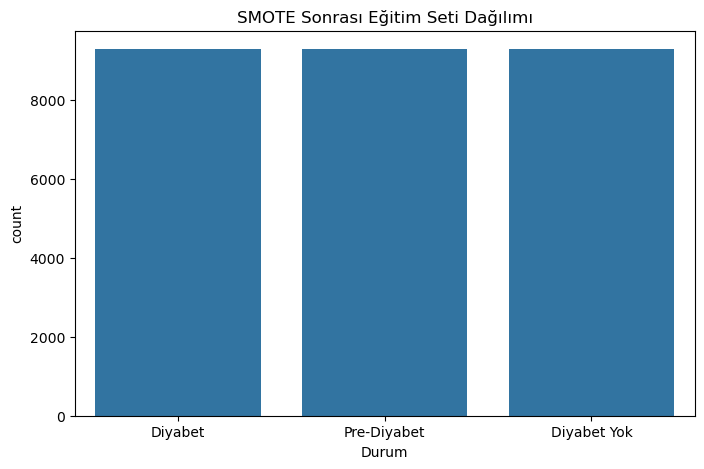

In [7]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# SMOTE uygulayalım (Sadece eğitim verisine!)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Orijinal eğitim seti sınıf dağılımı:', Counter(y_train))
print('Artırılmış eğitim seti sınıf dağılımı:', Counter(y_train_res))

# Sonuçları görselleştirelim
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train_res)
plt.title("SMOTE Sonrası Eğitim Seti Dağılımı")
plt.show()

In [12]:
%pip install xgboost imbalanced-learn scikit-learn
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Verileri Ölçeklendirelim
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # SMOTE'suz haliyle başlıyoruz
X_test_scaled = scaler.transform(X_test)

# Hedef değişkenimiz (y) artık kategorik değil, direkt 'Hemoglobin (Hb A1c)' sayısal değeridir.
# Not: Önceki adımda y_train ve y_test'i 'Durum' olarak ayırmıştık. 
# Onları sayısal HbA1c değerlerine geri çekiyoruz:
y_train_reg = df_final.loc[X_train.index, 'Hemoglobin (Hb A1c)']
y_test_reg = df_final.loc[X_test.index, 'Hemoglobin (Hb A1c)']

# 2. XGBRegressor Modelini Tanımlayalım
# Regresyon için özelleştirilmiş parametreler
reg_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    objective='reg:squarederror' # Hata kareler ortalamasını minimize eder
)

# 3. Modeli Eğitelim
reg_model.fit(
    X_train_scaled, y_train_reg,
    eval_set=[(X_test_scaled, y_test_reg)],
    verbose=False
)

print("Regresyon modeli eğitimi tamamlandı.")

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 4.8 MB/s eta 0:00:22
    --------------------------------------- 1.6/101.7 MB 4.5 MB/s eta 0:00:23
    --------------------------------------- 2.4/101.7 MB 4.0 MB/s eta 0:00:25
   - -------------------------------------- 2.9/101.7 MB 3.6 MB/s eta 0:00:28
   - -------------------------------------- 3.7/101.7 MB 3.7 MB/s eta 0:00:27
   - -------------------------------------- 4.7/101.7 MB 4.0 MB/s eta 0:00:25
   -- ------------------------------------- 5.5/101.7 MB 4.0 MB/s eta 0:00:24
   -- ------------------------------------- 6.6/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 7.6/101.7 MB 4.2 MB/s eta 0:00:23
   --- ------------------------------------ 8.7/101.7 MB 4.3 MB/s eta 0:00:22
   --- ------------------------------------ 9.7/101.7 MB 4.4 MB/s eta 0

--- REGRESYON PERFORMANS RAPORU ---
R2 Skoru (Başarı Oranı): %93.17
Ortalama Mutlak Hata (MAE): 0.1532 (Örn: 0.2 hata, 6.0 yerine 6.2 tahmin demektir)
RMSE: 0.4241


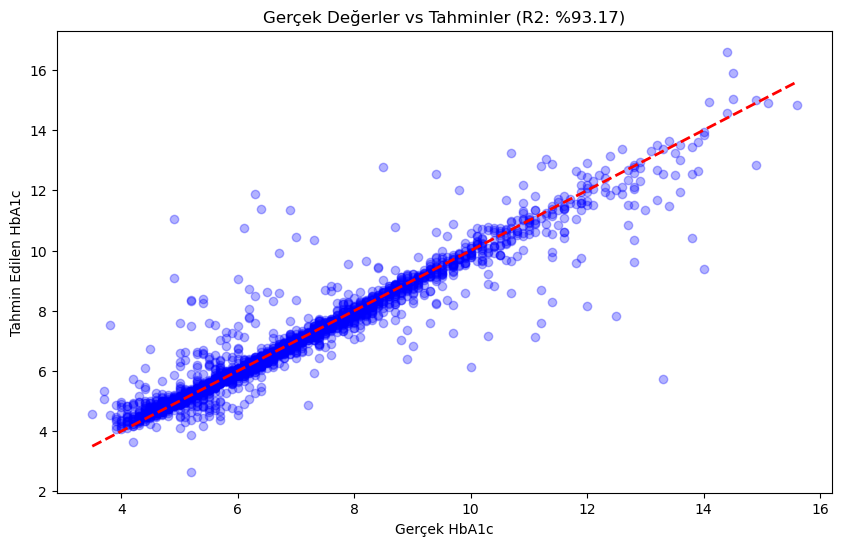

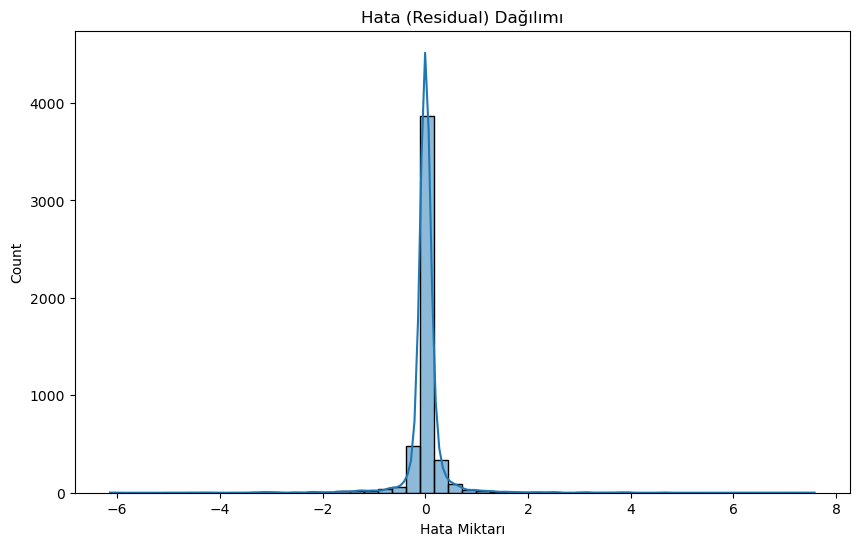

In [13]:
# Tahminleri alalım
y_pred = reg_model.predict(X_test_scaled)

# Metrikleri hesaplayalım
r2 = r2_score(y_test_reg, y_pred)
mae = mean_absolute_error(y_test_reg, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))

print("--- REGRESYON PERFORMANS RAPORU ---")
print(f"R2 Skoru (Başarı Oranı): %{r2*100:.2f}")
print(f"Ortalama Mutlak Hata (MAE): {mae:.4f} (Örn: 0.2 hata, 6.0 yerine 6.2 tahmin demektir)")
print(f"RMSE: {rmse:.4f}")

# Gerçek vs Tahmin Görselleştirmesi
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred, alpha=0.3, color='blue')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], '--r', linewidth=2)
plt.xlabel('Gerçek HbA1c')
plt.ylabel('Tahmin Edilen HbA1c')
plt.title(f'Gerçek Değerler vs Tahminler (R2: %{r2*100:.2f})')
plt.show()

# Hata Dağılımı
errors = y_test_reg - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(errors, bins=50, kde=True)
plt.title("Hata (Residual) Dağılımı")
plt.xlabel("Hata Miktarı")
plt.show()